In [150]:
import sys
from pathlib import Path

_cwd  = Path.cwd()
ROOT  = _cwd.parent if _cwd.name == "scripts" else _cwd
sys.path.insert(0, str(ROOT / "apps" / "api"))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

MODELS_DIR = ROOT / "outputs"
DATA_DIR   = ROOT / "data"

plt.rcParams["figure.figsize"] = (14, 4)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3

print("ROOT:", ROOT.resolve())

ROOT: C:\Users\trist\Dev\MSPR-TRPE932


## Chargement des données et modèles

In [151]:
df = pd.read_csv(DATA_DIR / "transformed_data.csv")
X  = df.drop(columns=["Consommation"])
y  = df["Consommation"]

n          = len(df)
split_tr   = int(n * 0.70)
split_cal  = int(n * 0.80)

X_train, X_calib, X_test = X.iloc[:split_tr], X.iloc[split_tr:split_cal], X.iloc[split_cal:]
y_train, y_calib, y_test = y.iloc[:split_tr], y.iloc[split_tr:split_cal], y.iloc[split_cal:]

print(f"Train : {len(X_train):,}  Calib : {len(X_calib):,}  Test : {len(X_test):,}")

Train : 176,744  Calib : 25,249  Test : 50,499


In [152]:
from utils import load_latest_model, load_quantile_models

model,   model_name = load_latest_model(str(MODELS_DIR))
p10_model, p90_model = load_quantile_models(str(MODELS_DIR))
imputer      = joblib.load(MODELS_DIR / "imputer.pkl")
feature_cols = joblib.load(MODELS_DIR / "feature_cols.pkl")
cqr_q        = joblib.load(MODELS_DIR / "cqr_correction.pkl")

print(f"Modèle : {model_name}  |  CQR q = {cqr_q:.1f} MW")

Modèle : model_xgboost_20260527_191958.pkl  |  CQR q = 361.1 MW


In [153]:
X_test_imp = imputer.transform(X_test.reindex(columns=feature_cols))

y_pred     = model.predict(X_test_imp)
y_p10      = p10_model.predict(X_test_imp) - cqr_q
y_p90      = p90_model.predict(X_test_imp) + cqr_q

y_true = y_test.values

c:\Users\trist\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but KNNImputer was fitted without feature names
  warnings.warn(


## Métriques sur le jeu de test

In [154]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

metrics = {
    "R²":             r2_score(y_true, y_pred),
    "RMSE (MW)":      np.sqrt(mean_squared_error(y_true, y_pred)),
    "MAPE":           mean_absolute_percentage_error(y_true, y_pred),
    "Accuracy ±5%":   float(np.mean(np.abs((y_true - y_pred) / y_true) < 0.05)),
    "Couverture 80%": float(np.mean((y_true >= y_p10) & (y_true <= y_p90))),
    "Largeur PI moy (MW)": float(np.mean(y_p90 - y_p10)),
}

pd.Series(metrics).rename("Valeur").to_frame()

,Valeur
R²,0.982675
RMSE (MW),1366.775199
MAPE,0.019128
Accuracy ±5%,0.942415
Couverture 80%,0.780689
Largeur PI moy (MW),3161.751709


## Prédit vs Réel — extrait de 2 semaines

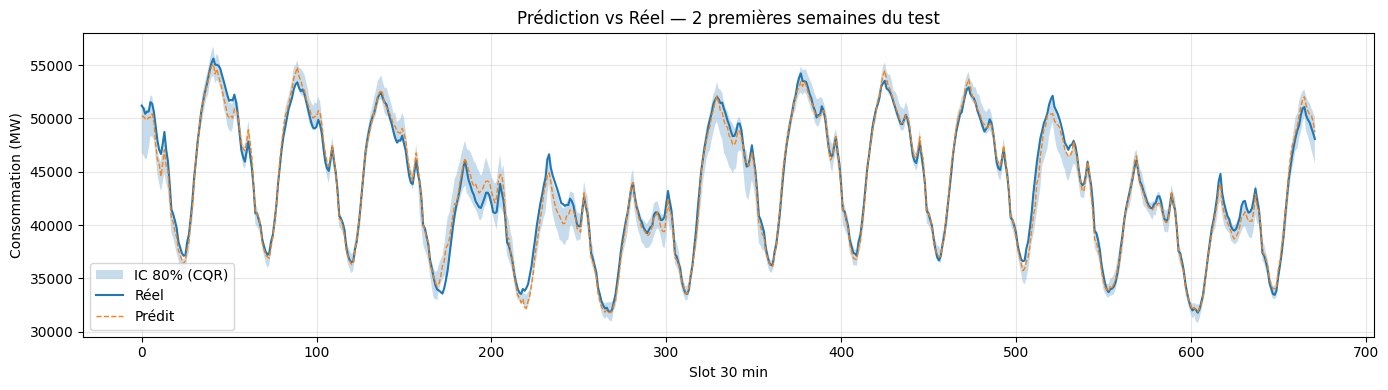

In [155]:
n_slots = 48 * 14  # 2 semaines

fig, ax = plt.subplots()
ax.fill_between(range(n_slots), y_p10[:n_slots], y_p90[:n_slots],
                alpha=0.25, label="IC 80% (CQR)")
ax.plot(y_true[:n_slots],  lw=1.5, label="Réel")
ax.plot(y_pred[:n_slots],  lw=1,   label="Prédit", linestyle="--")
ax.set_ylabel("Consommation (MW)")
ax.set_xlabel("Slot 30 min")
ax.legend()
ax.set_title("Prédiction vs Réel — 2 premières semaines du test")
plt.tight_layout()

## Distribution des erreurs

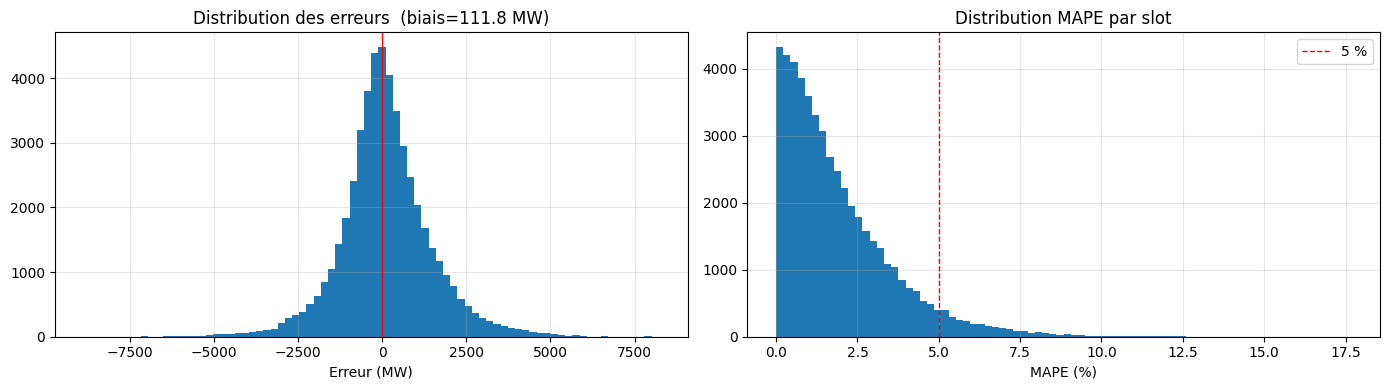

In [156]:
errors = y_pred - y_true

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(errors, bins=80, edgecolor="none")
axes[0].axvline(0, color="red", lw=1)
axes[0].set_xlabel("Erreur (MW)")
axes[0].set_title(f"Distribution des erreurs  (biais={errors.mean():.1f} MW)")

mape_pct = np.abs((y_pred - y_true) / y_true) * 100
axes[1].hist(mape_pct, bins=80, edgecolor="none")
axes[1].axvline(5, color="red", lw=1, linestyle="--", label="5 %")
axes[1].set_xlabel("MAPE (%)")
axes[1].set_title("Distribution MAPE par slot")
axes[1].legend()

plt.tight_layout()

## Erreur par heure de la journée

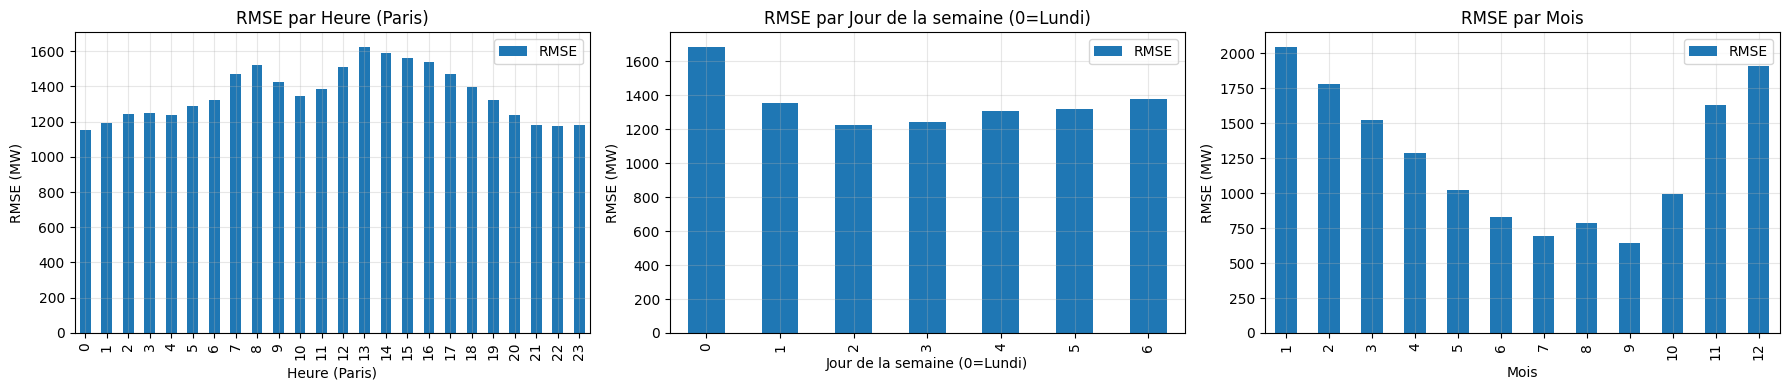

In [157]:
results = pd.DataFrame({"y_true": y_true, "y_pred": y_pred, "error": errors})

raw = pd.read_csv(DATA_DIR / "raw_data.csv", sep=";", encoding="utf-8-sig",
                  usecols=["Date et Heure"], low_memory=False)
raw["dt"] = pd.to_datetime(raw["Date et Heure"], utc=True)
raw = raw.sort_values("dt").reset_index(drop=True)

raw_test = raw.iloc[split_cal:split_cal + len(results)].reset_index(drop=True)
results["dt"] = raw_test["dt"].values

dt_paris = pd.to_datetime(results["dt"]).dt.tz_localize("UTC", ambiguous="infer").dt.tz_convert("Europe/Paris")
results["hour"]  = dt_paris.dt.hour
results["dow"]   = dt_paris.dt.dayofweek
results["month"] = dt_paris.dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col, label in [
    (axes[0], "hour",  "Heure (Paris)"),
    (axes[1], "dow",   "Jour de la semaine (0=Lundi)"),
    (axes[2], "month", "Mois"),
]:
    grp = results.groupby(col)["error"].agg(["mean", lambda x: np.sqrt((x**2).mean())])
    grp.columns = ["Biais", "RMSE"]
    grp[["RMSE"]].plot.bar(ax=ax, legend=True)
    ax.set_xlabel(label)
    ax.set_ylabel("RMSE (MW)")
    ax.set_title(f"RMSE par {label}")

plt.tight_layout()

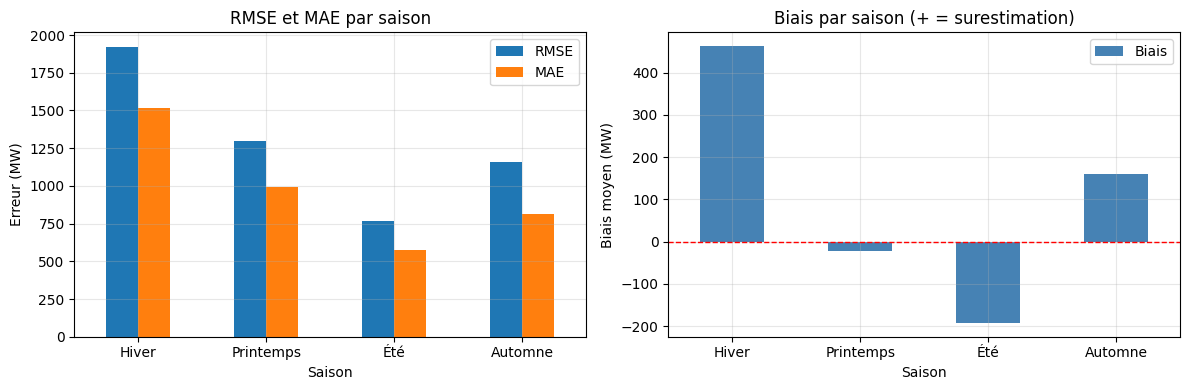

In [158]:
season_map = {12: "Hiver", 1: "Hiver", 2: "Hiver",
              3: "Printemps", 4: "Printemps", 5: "Printemps",
              6: "Été", 7: "Été", 8: "Été",
              9: "Automne", 10: "Automne", 11: "Automne"}
season_order = ["Hiver", "Printemps", "Été", "Automne"]

results["season"] = results["month"].map(season_map)

grp = results.groupby("season")["error"].agg(
    Biais="mean",
    RMSE=lambda x: np.sqrt((x**2).mean()),
    MAE=lambda x: np.abs(x).mean(),
).reindex(season_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

grp[["RMSE", "MAE"]].plot.bar(ax=axes[0])
axes[0].set_xlabel("Saison")
axes[0].set_ylabel("Erreur (MW)")
axes[0].set_title("RMSE et MAE par saison")
axes[0].tick_params(axis="x", rotation=0)

grp[["Biais"]].plot.bar(ax=axes[1], color="steelblue")
axes[1].axhline(0, color="red", lw=1, linestyle="--")
axes[1].set_xlabel("Saison")
axes[1].set_ylabel("Biais moyen (MW)")
axes[1].set_title("Biais par saison (+ = surestimation)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()

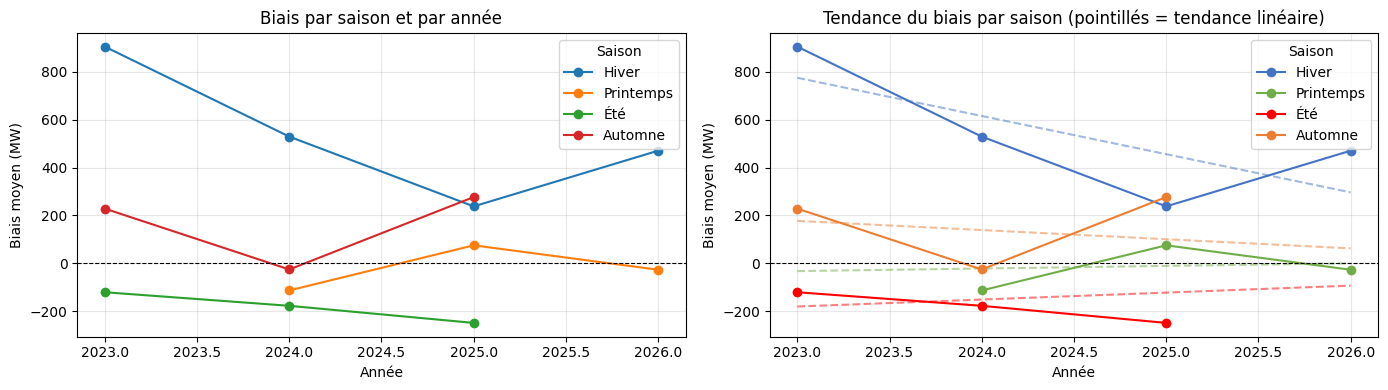

In [159]:
results["year"] = pd.to_datetime(results["dt"]).dt.tz_localize("UTC", ambiguous="infer").dt.tz_convert("Europe/Paris").dt.year

pivot = results.groupby(["year", "season"])["error"].mean().unstack("season")[season_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pivot.plot(ax=axes[0], marker="o")
axes[0].axhline(0, color="black", lw=0.8, linestyle="--")
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Biais moyen (MW)")
axes[0].set_title("Biais par saison et par année")
axes[0].legend(title="Saison")

for season, color in zip(season_order, ["#4472C4", "#70AD47", "#FF0000", "#ED7D31"]):
    if season in pivot.columns:
        axes[1].plot(pivot.index, pivot[season], marker="o", label=season, color=color)
        z = np.polyfit(pivot.index, pivot[season].fillna(0), 1)
        axes[1].plot(pivot.index, np.poly1d(z)(pivot.index), linestyle="--", color=color, alpha=0.5)
axes[1].axhline(0, color="black", lw=0.8, linestyle="--")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Biais moyen (MW)")
axes[1].set_title("Tendance du biais par saison (pointillés = tendance linéaire)")
axes[1].legend(title="Saison")

plt.tight_layout()

## Scatter : Prédit vs Réel

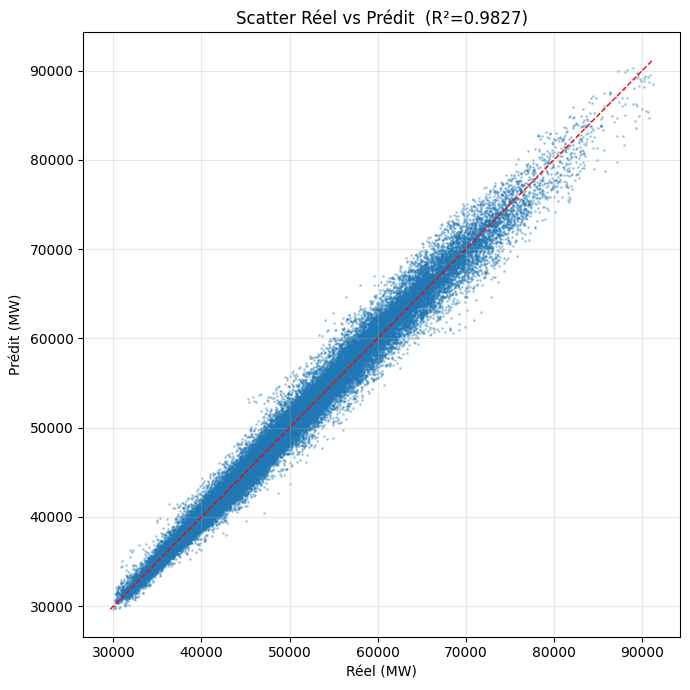

In [160]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true, y_pred, s=1, alpha=0.3)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Réel (MW)")
ax.set_ylabel("Prédit (MW)")
ax.set_title(f"Scatter Réel vs Prédit  (R²={metrics['R²']:.4f})")
plt.tight_layout()

## Importance des features (top 30)

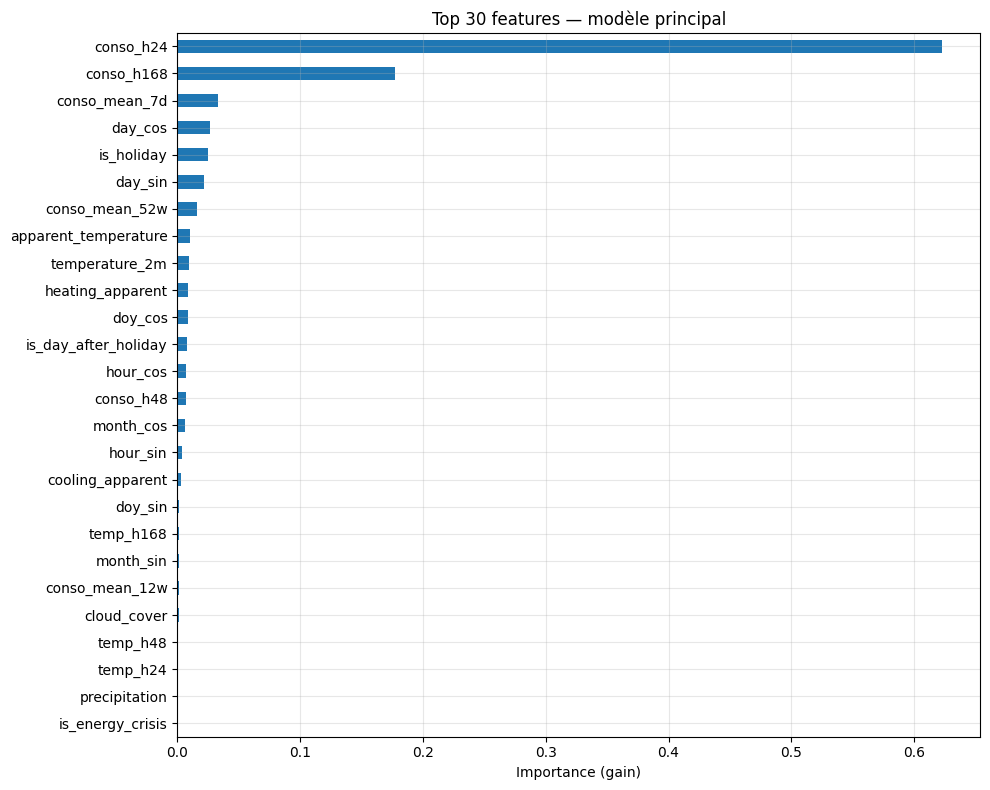

In [161]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
top30 = importances.nlargest(30).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
top30.plot.barh(ax=ax)
ax.set_xlabel("Importance (gain)")
ax.set_title("Top 30 features — modèle principal")
plt.tight_layout()

## SHAP — Contributions des features

In [162]:
import shap

N_SHAP = 2000
rng    = np.random.default_rng(42)
idx    = rng.choice(len(X_test_imp), size=N_SHAP, replace=False)
X_shap = X_test_imp[idx]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP calculé sur {N_SHAP} slots du test set")

SHAP calculé sur 2000 slots du test set


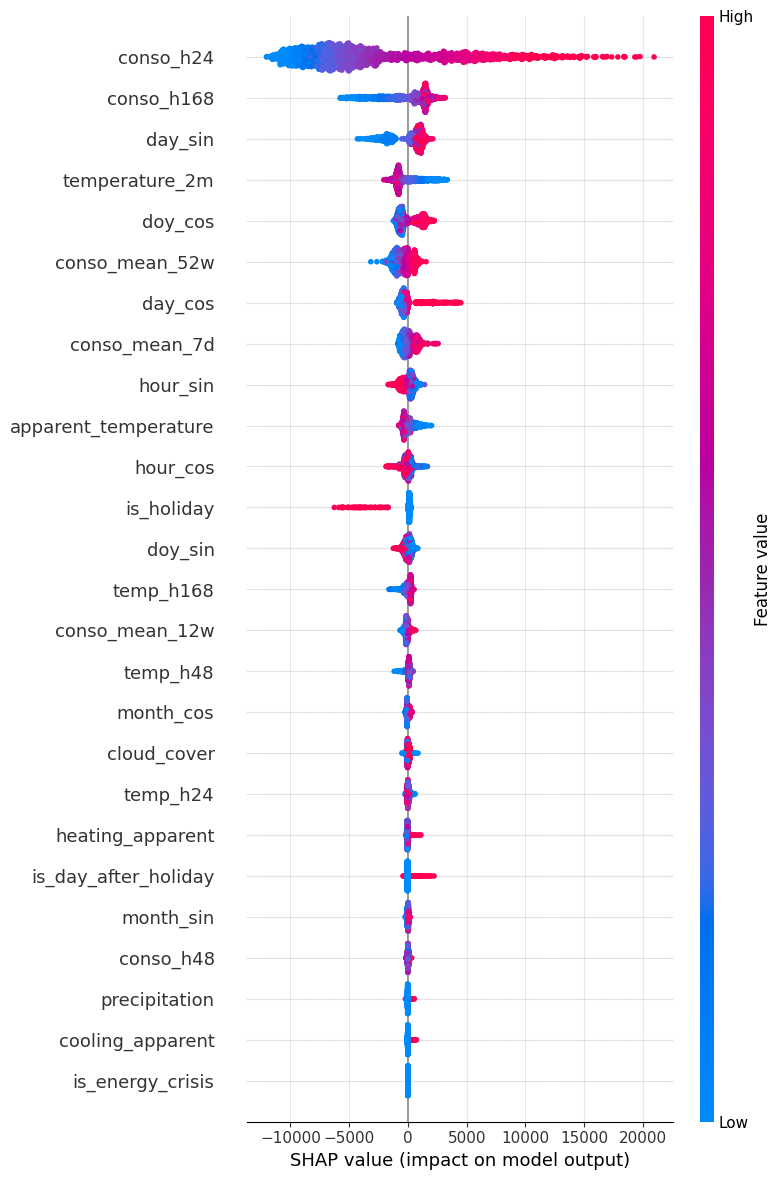

In [163]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, max_display=30)

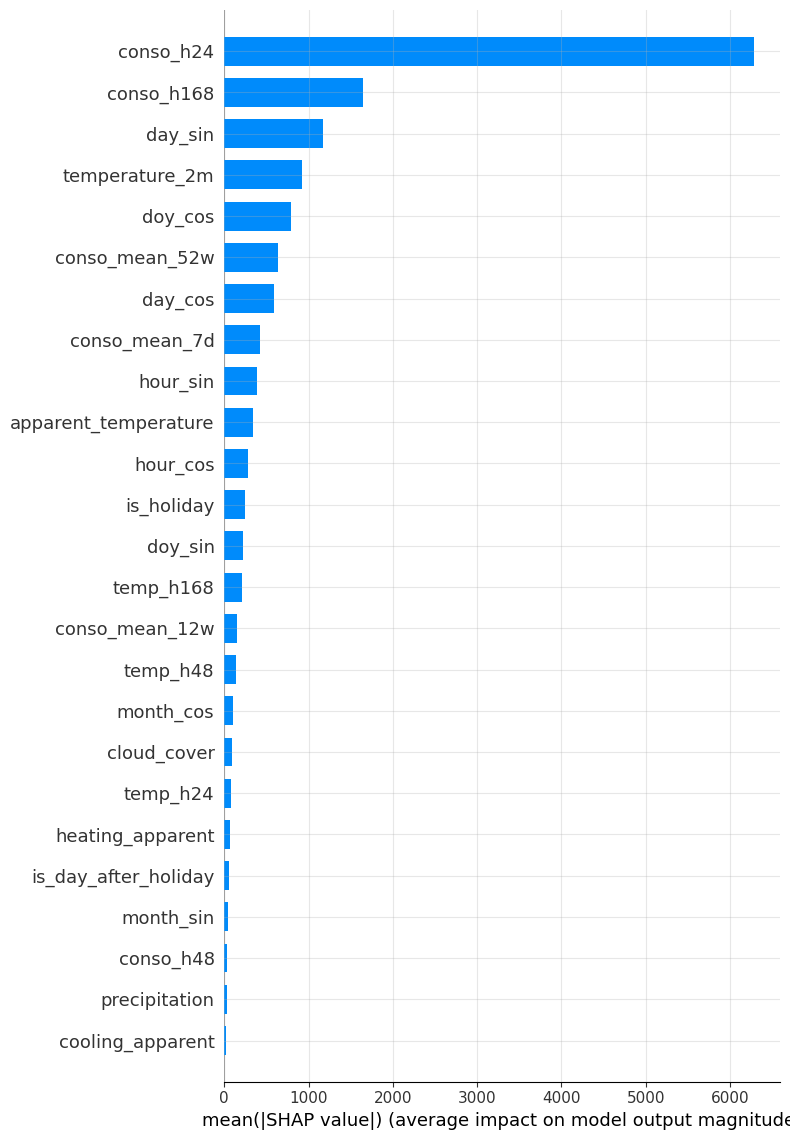

In [164]:
shap.summary_plot(shap_values, X_shap, feature_names=feature_cols, max_display=25, plot_type="bar")

## Couverture de l'intervalle de confiance par mois

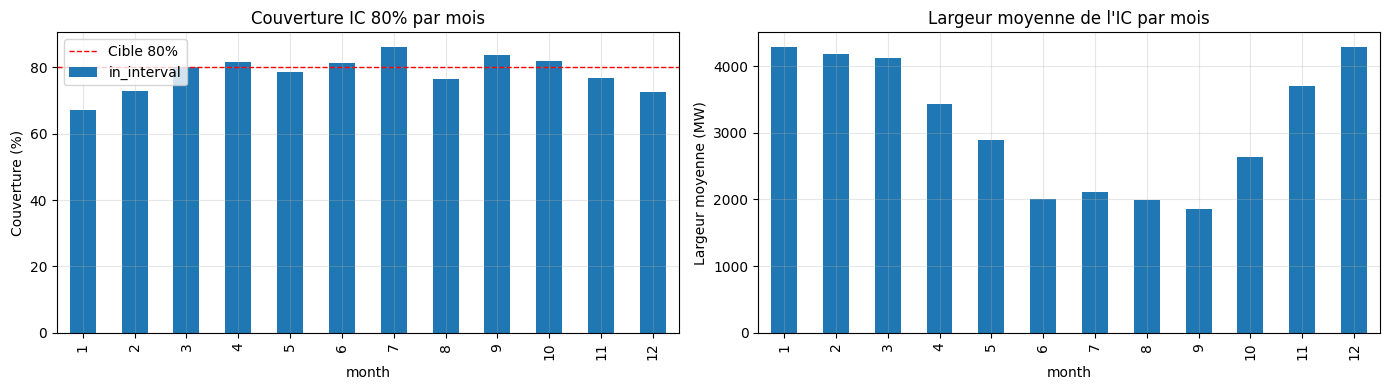

In [165]:
results["in_interval"] = (y_true >= y_p10) & (y_true <= y_p90)
results["pi_width"]    = y_p90 - y_p10

coverage = results.groupby("month")["in_interval"].mean() * 100
width    = results.groupby("month")["pi_width"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

coverage.plot.bar(ax=axes[0])
axes[0].axhline(80, color="red", lw=1, linestyle="--", label="Cible 80%")
axes[0].set_ylabel("Couverture (%)")
axes[0].set_title("Couverture IC 80% par mois")
axes[0].legend()

width.plot.bar(ax=axes[1])
axes[1].set_ylabel("Largeur moyenne (MW)")
axes[1].set_title("Largeur moyenne de l'IC par mois")

plt.tight_layout()